In [1]:
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import pickle
import pingouin as pg
import pathlib
 

import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u

from STX3KO_analyses.hse import HSE
import TwoPUtils as tpu

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['font.serif'] = 'Arial'


%matplotlib inline


In [2]:
def get_reward_cells_across_days(sess, align_day):

    rz_early = (np.argwhere(sess.trial_matrices['bin_edges'][:-1]>=sess.rzone_early['tfront'])[0], np.argwhere(sess.rzone_early['tback']<=sess.trial_matrices['bin_edges'][1:])[0] )
    rz_late = (np.argwhere(sess.trial_matrices['bin_edges'][:-1]>=sess.rzone_late['tfront'])[0], 29 )

    if sess.novel_arm == 1: 
        rz_nov = rz_late
        rz_fam = rz_early
    else: 
        rz_nov = rz_early
        rz_fam = rz_late

    pc_mask = sess.fam_place_cell_mask()+sess.nov_place_cell_mask()
    # print(pc_mask.shape)

    nov_mask= sess.trial_info['LR']==sess.novel_arm
    
    day_mask = sess.trial_info['sess_num']==align_day

    tmat_nov = np.nanmean(sess.trial_matrices['F_dff'][nov_mask*day_mask,:,:][:,:,pc_mask], axis=0)
    maxpos_nov = np.nanargmax(tmat_nov, axis=0)
    rel_pos_nov = maxpos_nov-rz_nov[0]
    rz_cell_nov = (maxpos_nov>=(rz_nov[0]-5)) * (maxpos_nov<=(rz_nov[0]-1))

    tmat_fam = np.nanmean(sess.trial_matrices['F_dff'][~nov_mask*day_mask,:,:][:,:,pc_mask], axis=0)
    # print(tmat_fam.shape)
    maxpos_fam = np.nanargmax(tmat_fam, axis=0)
    rel_pos_fam = maxpos_fam - rz_fam[0]
    rz_cell_fam = (maxpos_fam>=(rz_fam[0]-5)) * (maxpos_fam<=(rz_fam[0]-1))

    r_cell_mask = rz_cell_fam * rz_cell_nov * (np.abs(rel_pos_fam-rel_pos_nov)<=2)
    pc_dict = {}
    for day in range(6):
        pc_dict[day] = {}
        day_mask = sess.trial_info['sess_num']==day
        for ttype in ('nov', 'fam'):
            if ttype == 'nov':
                n_mask = nov_mask
                rz = rz_nov
            else:
                n_mask = ~nov_mask
                rz = rz_fam
                
            day_tmat = np.nanmean(sess.trial_matrices['F_dff'][n_mask*day_mask,:,:][:,:,pc_mask],axis=0)
            pc_dict[day][ttype] = np.roll(day_tmat[:,r_cell_mask],15-rz[0], axis=0)
    return pc_dict




In [3]:
rcell_day = 5
pc_dict= {}
for cond, mice in zip(('ctrl', 'ko'), (ctrl_mice, ko_mice)):
    pc_dict[cond] = {}
    for mouse in mice:
        sess = u.single_mouse_concat_sessions(mouse, np.arange(6))
        pc_dict[cond][mouse] = get_reward_cells_across_days(sess,rcell_day)

29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel
29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel
29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel
29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel
29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


05_12_2020 YMaze_LNovel
14_10_2021 YMaze_LNovel
15_10_2021 YMaze_LNovel
16_10_2021 YMaze_LNovel
17_10_2021 YMaze_LNovel
18_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
14_10_2021 YMaze_LNovel
15_10_2021 YMaze_LNovel
16_10_2021 YMaze_LNovel
17_10_2021 YMaze_LNovel
18_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
14_10_2021 YMaze_LNovel
15_10_2021 YMaze_LNovel
16_10_2021 YMaze_LNovel
17_10_2021 YMaze_LNovel
18_10_2021 YMaze_LNovel
20_10_2021 YMaze_LNovel
15_10_2021 YMaze_LNovel
16_10_2021 YMaze_LNovel
17_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
20_10_2021 YMaze_LNovel
21_10_2021 YMaze_LNovel


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


28_09_2020 YMaze_LNovel


...

01_10_2020 YMaze_LNovel


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


02_10_2020 YMaze_LNovel


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


03_10_2020 YMaze_LNovel
28_09_2020 YMaze_LNovel
29_09_2020 YMaze_LNovel
30_09_2020 YMaze_LNovel
01_10_2020 YMaze_LNovel
02_10_2020 YMaze_LNovel
03_10_2020 YMaze_LNovel
28_09_2020 YMaze_LNovel
29_09_2020 YMaze_LNovel
30_09_2020 YMaze_LNovel
01_10_2020 YMaze_LNovel
02_10_2020 YMaze_LNovel
03_10_2020 YMaze_LNovel
18_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
20_10_2021 YMaze_LNovel
21_10_2021 YMaze_LNovel
22_10_2021 YMaze_LNovel
23_10_2021 YMaze_LNovel
18_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
20_10_2021 YMaze_LNovel
21_10_2021 YMaze_LNovel
23_10_2021 YMaze_LNovel
23_10_2021 YMaze_LNovel


In [4]:
plot_dict = {}
for cond, mice in zip(('ctrl', 'ko'),(ctrl_mice, ko_mice)):
    plot_dict[cond]={}
    for ttype in ('fam', 'nov'):
        plot_dict[cond][ttype] = {}
        for day in range(6):

            arr = []

            for mouse in mice:
                arr.append(pc_dict[cond][mouse][day][ttype])
            plot_dict[cond][ttype][day]= np.hstack(arr)


# sort_tmat = pc_dict[5]['fam']
# sort = np.argsort(np.nanargmax(sort_tmat, axis=0))

# fig, ax = plt.subplots(2,6)
# for i,nov in enumerate(('fam','nov')):
#     for day in range(6):
#         tmat = pc_dict[day][nov]
#         ax[i,day].imshow(tmat[:,sort].T,aspect='auto')

In [8]:
plot_dict['ctrl']['fam'][5].shape

(30, 320)

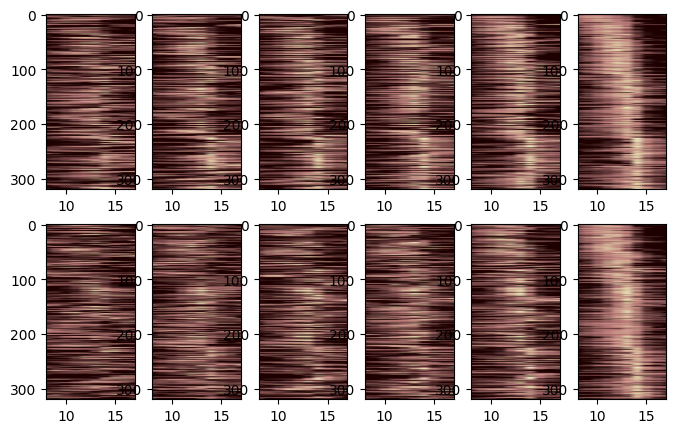

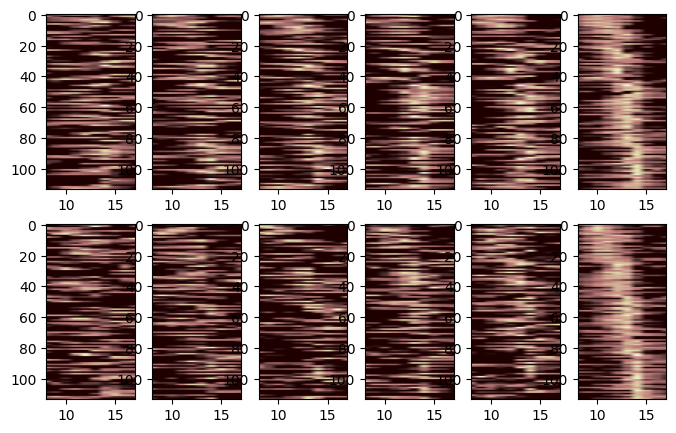

In [24]:
for cond in ('ctrl', 'ko'):
    sort_tmat = plot_dict[cond]['fam'][5] + plot_dict[cond]['nov'][5]
    sort = np.argsort(np.nanargmax(sort_tmat, axis=0))

    fig, ax = plt.subplots(2,6, figsize=[8,5])
    for i,nov in enumerate(('fam','nov')):
        for day in range(6):
            tmat = sp.stats.zscore(plot_dict[cond][nov][day],axis=0)
            ax[i,day].imshow(tmat[:,sort].T,aspect='auto', cmap='pink', vmin=0, vmax=5)
            ax[i,day].set_xlim([8,17])